# 9. Revision — External Figures S3 & S4 (regenerated for the deployed model)

**Purpose.** Figures S3 (external ROC + calibration) and S4 (external Kaplan–Meier by ML risk group) were carried over from the original submission and still showed the pre-harmonization values. This notebook regenerates both from the **deployed finalized model** (`model/final_model_calibrated.pkl`), consistent with the harmonized external Table 3 (notebook 8). The AJCC comparator in Figure S3 uses the derivation-trained logistic model applied to the external cohort (AUC 0.610), matching Table 3.

Risk stratification at the prespecified cutoff (0.12) shifts negligibly, so the survival message is unchanged.

In [1]:
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import numpy as np, pandas as pd, joblib
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.calibration import calibration_curve
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from lifelines.plotting import add_at_risk_counts
SEED = 8251; HIGH='#d62728'; LOW='#1f77b4'
def find_data_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        for cand in (base/'local_data', base/'stage_III_colon_edr'/'local_data'):
            if cand.exists(): return cand
    raise FileNotFoundError('Place a local_data/ folder (prepared parquet/CSV) in the repo root; see README.')
def find_model_dir():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base/'model'/'final_model_calibrated.pkl').exists(): return base/'model'
    raise FileNotFoundError('model/ not found')
DATA, MODEL = find_data_dir(), find_model_dir()
feat = list(joblib.load(MODEL/'final_feature_columns.pkl')); PKL = joblib.load(MODEL/'final_model_calibrated.pkl')
deriv = pd.read_parquet(DATA/'all_cases_prepared_for_ML.parquet')
ext   = pd.read_parquet(DATA/'EDA_Ext_Val.parquet').copy()   # external cohort with DFS survival data
print('External n=%d, EDR-18 events=%d, DFS events=%d' % (len(ext), int(ext.edr_18m.sum()), int(ext.DFS_Events.sum())))

External n=142, EDR-18 events=19, DFS events=56


In [2]:
def dummies(df):
    X = pd.get_dummies(df[['AJCC_Substage','PNI','LNR','Differentiation']], columns=['AJCC_Substage'])
    X['PNI'] = X['PNI'].astype(float); X['Differentiation'] = X['Differentiation'].astype(float)
    return X.replace([np.inf,-np.inf], np.nan)
Xe = dummies(ext).reindex(columns=feat, fill_value=0)
y_ext = ext['edr_18m'].astype(int).values
# XGBoost = deployed model; AJCC = derivation-trained -> external (matches Table 3)
p_xgb = PKL.predict_proba(Xe)[:,1]
Xd = dummies(deriv); yd = deriv['edr_18m'].astype(int)
ajcc_cols = [c for c in Xd.columns if 'AJCC' in c]
lr = LogisticRegression(C=1e9, class_weight='balanced', solver='liblinear', random_state=SEED).fit(Xd[ajcc_cols], yd)
p_ajcc = lr.predict_proba(Xe[ajcc_cols])[:,1]
auc_xgb = roc_auc_score(y_ext, p_xgb); auc_ajcc = roc_auc_score(y_ext, p_ajcc); brier = brier_score_loss(y_ext, p_xgb)
print('External XGBoost AUC = %.3f (Brier %.3f) | AJCC AUC = %.3f' % (auc_xgb, brier, auc_ajcc))

External XGBoost AUC = 0.633 (Brier 0.130) | AJCC AUC = 0.610


## Figure S3 — External ROC + calibration (deployed model)

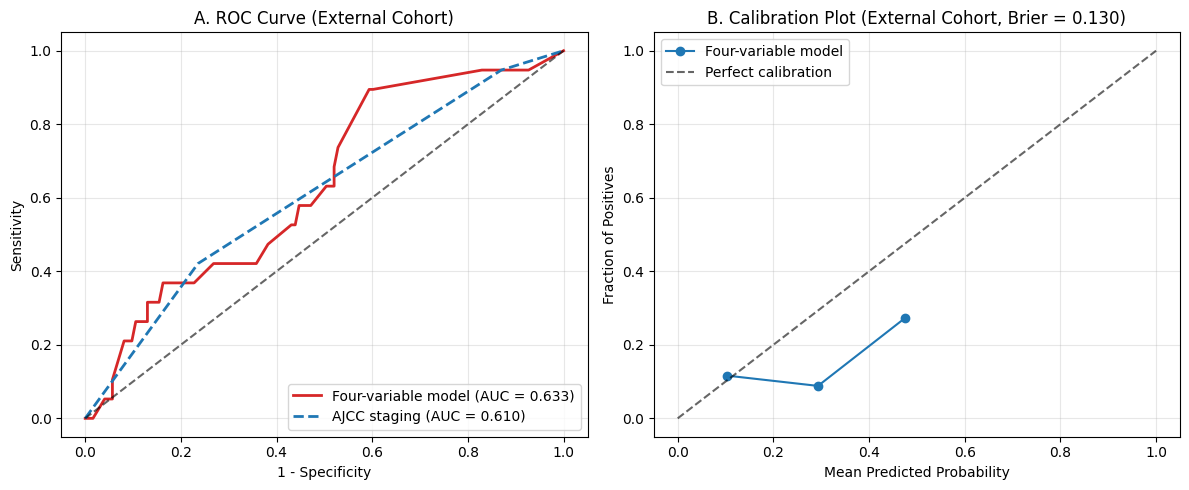

In [3]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
fpr,tpr,_ = roc_curve(y_ext, p_xgb); fa,ta,_ = roc_curve(y_ext, p_ajcc)
plt.plot(fpr,tpr,color='#d62728',lw=2,label='Four-variable model (AUC = %.3f)' % auc_xgb)
plt.plot(fa,ta,color='#1f77b4',lw=2,linestyle='--',label='AJCC staging (AUC = %.3f)' % auc_ajcc)
plt.plot([0,1],[0,1],'k--',alpha=0.6)
plt.xlabel('1 - Specificity'); plt.ylabel('Sensitivity'); plt.title('A. ROC Curve (External Cohort)')
plt.legend(loc='lower right'); plt.grid(True,alpha=0.3)
plt.subplot(1,2,2)
pt,pp = calibration_curve(y_ext, p_xgb, n_bins=5)
plt.plot(pp,pt,marker='o',color='#1f77b4',label='Four-variable model')
plt.plot([0,1],[0,1],'k--',alpha=0.6,label='Perfect calibration')
plt.xlabel('Mean Predicted Probability'); plt.ylabel('Fraction of Positives')
plt.title('B. Calibration Plot (External Cohort, Brier = %.3f)' % brier)
plt.legend(loc='upper left'); plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.savefig('Figure_S3_External_Calibration_Performance.tiff', format='tiff', dpi=600)
plt.savefig('Figure_S3_External_Calibration_Performance.png', dpi=300)
plt.show()

## Figure S4 — External Kaplan–Meier by ML risk group + Cox HR

Risk groups (all): {'High Risk': 77, 'Low Risk': 65}


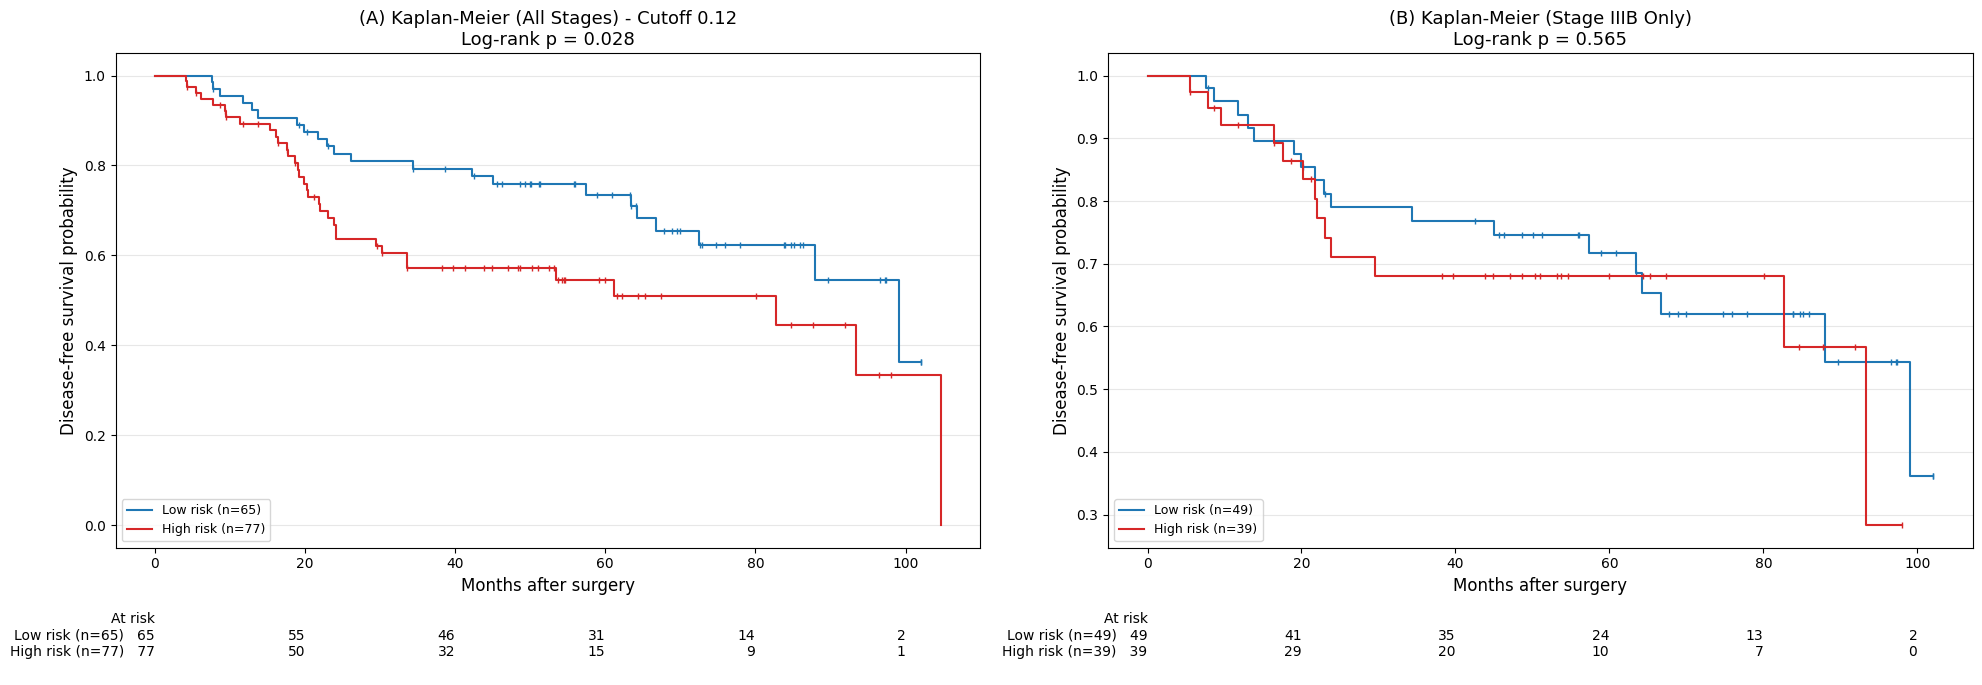

External, all stage III: HR=1.83 [1.06-3.16], p=0.030
External, Stage IIIB only: HR=1.24 [0.60-2.56], p=0.565


In [4]:
cutoff = 0.120
ext['Predicted_Prob'] = p_xgb
ext['Risk_Group'] = np.where(p_xgb >= cutoff, 'High Risk', 'Low Risk')
print('Risk groups (all):', ext['Risk_Group'].value_counts().to_dict())
def plot_km(data, title, ax):
    lo = data[data['Risk_Group']=='Low Risk']; hi = data[data['Risk_Group']=='High Risk']
    kl = KaplanMeierFitter(label='Low risk (n=%d)'%len(lo)).fit(lo['DFS_Months'], lo['DFS_Events'])
    kh = KaplanMeierFitter(label='High risk (n=%d)'%len(hi)).fit(hi['DFS_Months'], hi['DFS_Events'])
    kl.plot_survival_function(ax=ax, color=LOW, ci_show=False, show_censors=True, censor_styles={'ms':5,'marker':'|'})
    kh.plot_survival_function(ax=ax, color=HIGH, ci_show=False, show_censors=True, censor_styles={'ms':5,'marker':'|'})
    if len(hi) and len(lo):
        r = logrank_test(hi['DFS_Months'], lo['DFS_Months'], event_observed_A=hi['DFS_Events'], event_observed_B=lo['DFS_Events'])
        pt = 'Log-rank p < 0.001' if r.p_value<0.001 else 'Log-rank p = %.3f'%r.p_value
        ax.set_title('%s\n%s'%(title, pt), fontsize=13)
    else:
        ax.set_title(title, fontsize=13)
    ax.set_xlabel('Months after surgery', fontsize=12)
    ax.set_ylabel('Disease-free survival probability', fontsize=12); ax.grid(axis='y', alpha=0.3); ax.legend(loc='lower left', fontsize=9)
    if len(hi) and len(lo): add_at_risk_counts(kl, kh, ax=ax, rows_to_show=['At risk'])
fig, axes = plt.subplots(1,2,figsize=(20,7))
plot_km(ext, '(A) Kaplan-Meier (All Stages) - Cutoff %.2f' % cutoff, axes[0])
df_iiib = ext[ext['AJCC_Substage']=='3B'].copy()
plot_km(df_iiib, '(B) Kaplan-Meier (Stage IIIB Only)', axes[1])
plt.tight_layout()
plt.savefig('Figure_S4_KM_Risk_Stratified_External.tiff', format='tiff', dpi=600)
plt.savefig('Figure_S4_KM_Risk_Stratified_External.png', dpi=300)
plt.show()
def cox(df, lab):
    d = df[['DFS_Months','DFS_Events','Risk_Group']].copy(); d['Risk_High'] = (d['Risk_Group']=='High Risk').astype(int)
    if d['Risk_High'].nunique()<2 or d['DFS_Events'].sum()==0: print(lab, 'n/a'); return
    s = CoxPHFitter().fit(d[['DFS_Months','DFS_Events','Risk_High']], 'DFS_Months', 'DFS_Events').summary.loc['Risk_High']
    print('%s: HR=%.2f [%.2f-%.2f], p=%.3f' % (lab, s['exp(coef)'], s['exp(coef) lower 95%'], s['exp(coef) upper 95%'], s['p']))
cox(ext, 'External, all stage III')
cox(df_iiib, 'External, Stage IIIB only')

## Summary — Figure S3 / S4 updates

| Item | previous | regenerated |
|---|---|---|
| Fig S3 · XGBoost external AUC | 0.637 | **0.633** |
| Fig S3 · AJCC external AUC | 0.617 (within-cohort CV) | **0.610** (derivation-trained, matches Table 3) |
| Fig S3 · external Brier | 0.128 | **0.130** |
| Fig S4 · DFS HR (all stage III) | 1.84 (1.07–3.17) | **1.83 (1.06–3.16)** |
| Fig S4 · log-rank p | 0.026 | **0.028** |

All differences are negligible; the risk-stratified survival separation is unchanged. External Table 3 and both DeLong comparisons are in notebook 8.